C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_med'] = df[med_cols].astype(str).agg(" ".join, axis=1).str.contains(pattern, case=False, na=False)
C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"score_{base}"] = df[cols].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.'), errors="coerce")).mean(axis=1)
C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:43: Pe

Total samples loaded: 24497


C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_med'] = df[med_cols].astype(str).agg(" ".join, axis=1).str.contains(pattern, case=False, na=False)
C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"score_{base}"] = df[cols].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.'), errors="coerce")).mean(axis=1)
C:\Users\karlw\AppData\Local\Temp\ipykernel_38452\2920465539.py:43: Pe

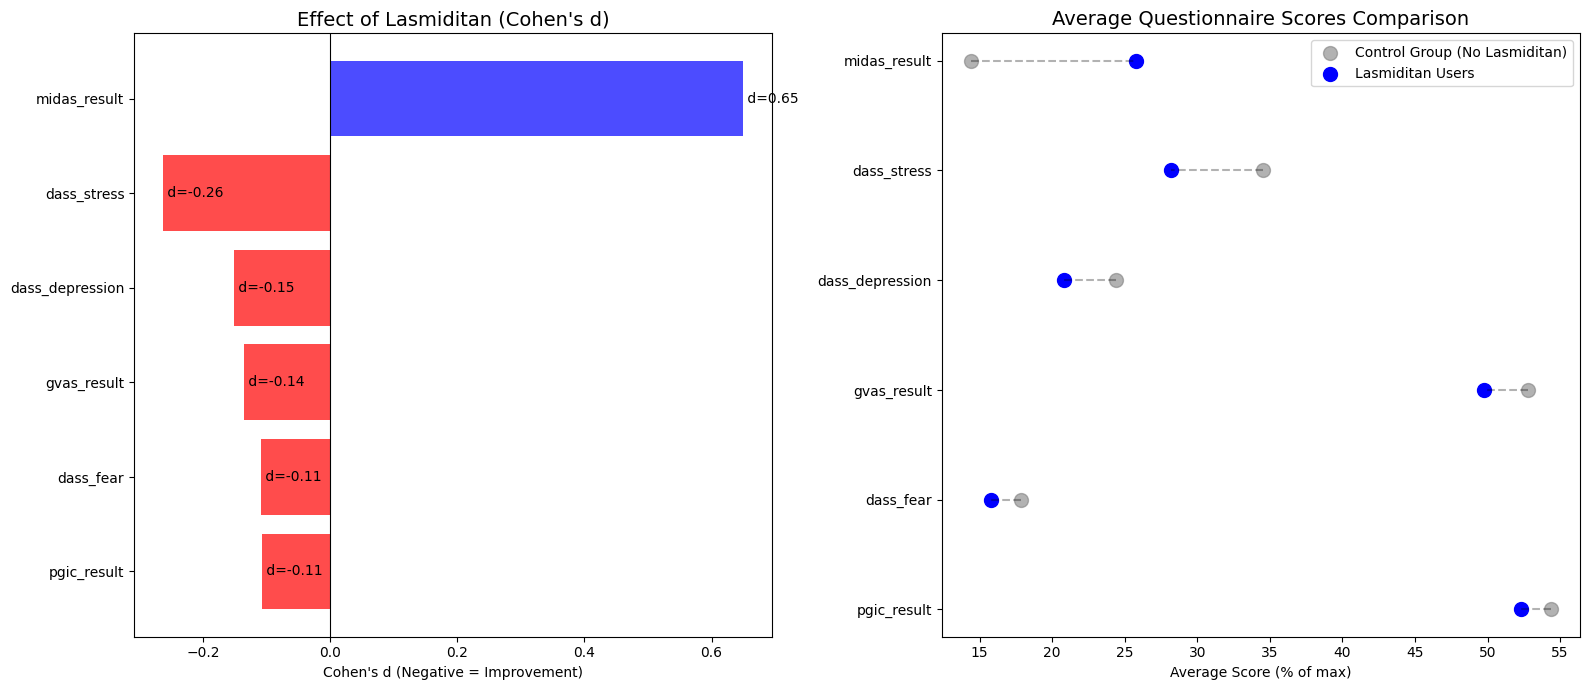

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re
import textwrap
from scipy.stats import ttest_ind

# =========================================================
# CONFIG
# =========================================================
DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
MEDICATION_QUERY = "Lasmiditan"
score_bases = ["midas_result", "dass_depression", "dass_fear", "dass_stress", "gvas_result", "pgic_result"]

score_ranges = {
    "pgic_result": 7,
    "dass_depression": 21,  # Corrected from 24
    "dass_fear": 21,
    "dass_stress": 21,      # Corrected from 42
    "gvas_result": 100,
    "midas_result": 279     # Based on data max
}
pattern = rf"\b{re.escape(MEDICATION_QUERY)}"

# =========================================================
# DATA LOADING (LOAD ONCE)
# =========================================================
combined_data = []
for file in csv_files:
    df = pd.read_csv(file, sep=";")
    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols: continue
    
    # Extract medication flag
    df['has_med'] = df[med_cols].astype(str).agg(" ".join, axis=1).str.contains(pattern, case=False, na=False)
    
    # Extract scores
    relevant_cols = ['has_med']
    for base in score_bases:
        cols = [c for c in df.columns if c.startswith(base)]
        if cols:
            df[f"score_{base}"] = df[cols].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.'), errors="coerce")).mean(axis=1)
            relevant_cols.append(f"score_{base}")
    
    combined_data.append(df[relevant_cols])

data = pd.concat(combined_data, ignore_index=True)
print("Total samples loaded:", len(data))

# =========================================================
# ANALYSIS PER SCORE TYPE
# =========================================================
results = []
for base in score_bases:
    col = f"score_{base}"
    if col not in data.columns: continue
    
    tmp = data[['has_med', col]].dropna()
    med_s = tmp[tmp['has_med']][col]
    ctrl_s = tmp[~tmp['has_med']][col]
    
    if len(med_s) < 5 or len(ctrl_s) < 5: continue
    
    # Convert to percentage for normalized comparison
    max_range = score_ranges.get(base, 100)
    med_pct = (med_s / max_range) * 100
    ctrl_pct = (ctrl_s / max_range) * 100
    
    # Cohen's d
    pooled_std = np.sqrt(((len(med_pct)-1)*med_pct.var() + (len(ctrl_pct)-1)*ctrl_pct.var()) / (len(med_pct)+len(ctrl_pct)-2))
    d = (med_pct.mean() - ctrl_pct.mean()) / pooled_std if pooled_std != 0 else 0
    
    results.append({
        "questionnaire": base,
        "mean_med_pct": med_pct.mean(),
        "mean_ctrl_pct": ctrl_pct.mean(),
        "cohens_d": d,
        "n_med": len(med_s),
        "n_ctrl": len(ctrl_s)
    })

res = pd.DataFrame(results).sort_values("cohens_d", key=abs)
res["questionnaire_wrapped"] = res["questionnaire"].apply(lambda x: textwrap.fill(str(x), width=15))

# =========================================================
# IMPROVED PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Cohen's d
colors = ['red' if x < 0 else 'blue' for x in res['cohens_d']]
bars = ax1.barh(res["questionnaire_wrapped"], res["cohens_d"], color=colors, alpha=0.7)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_title(f"Effect of {MEDICATION_QUERY} (Cohen's d)", fontsize=14)
ax1.set_xlabel("Cohen's d (Negative = Improvement)")
for i, bar in enumerate(bars):
    val = res["cohens_d"].iloc[i]
    ha = 'left' if val >= 0 else 'right'
    offset = 0.02 if val >= 0 else -0.02
    ax1.text(val + offset, bar.get_y() + bar.get_height()/2, f'd={val:.2f}', va='center', ha=ha)

# Plot 2: Absolute Comparison
y = np.arange(len(res))
ax2.scatter(res["mean_ctrl_pct"], y, color='gray', label="Control Group (No Lasmiditan)", s=100, alpha=0.6)
ax2.scatter(res["mean_med_pct"], y, color='blue', label=f"{MEDICATION_QUERY} Users", s=100)
for i in range(len(res)):
    ax2.plot([res["mean_ctrl_pct"].iloc[i], res["mean_med_pct"].iloc[i]], [i, i], color='black', alpha=0.3, linestyle='--')
ax2.set_yticks(y)
ax2.set_yticklabels(res["questionnaire_wrapped"])
ax2.set_xlabel("Average Score (% of max)")
ax2.set_title("Average Questionnaire Scores Comparison", fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()